In [32]:
import torch

In [49]:


def load_embedding_data(filepath='embedding_data.npy'):
    """
    Load embedding data from a saved file
    
    Args:
        filepath (str): Path to load the embedding data from
    
    Returns:
        np.ndarray: Loaded embedding data
    """

    file = torch.load(filepath)
    embeddings = file['hidden_states']
    emd = []
    for embedding in embeddings:
        hidde_norrm = embedding["model.norm"]
        emd.append(hidde_norrm)
    emb = torch.cat(emd, dim=0)

    return emb

embeddings_of_hidden = load_embedding_data("/mnt/abka03/xl-vlms/features/modified_save_hidden_states_qwen2_image_patched_patch_concept_generation_split_train.pth")

print(embeddings_of_hidden.shape)

torch.Size([12144, 1, 3584])


Epoch 0
Training Loss: 0.1912
Validation Loss: 0.0046
Model saved to sparse_encoder.pth


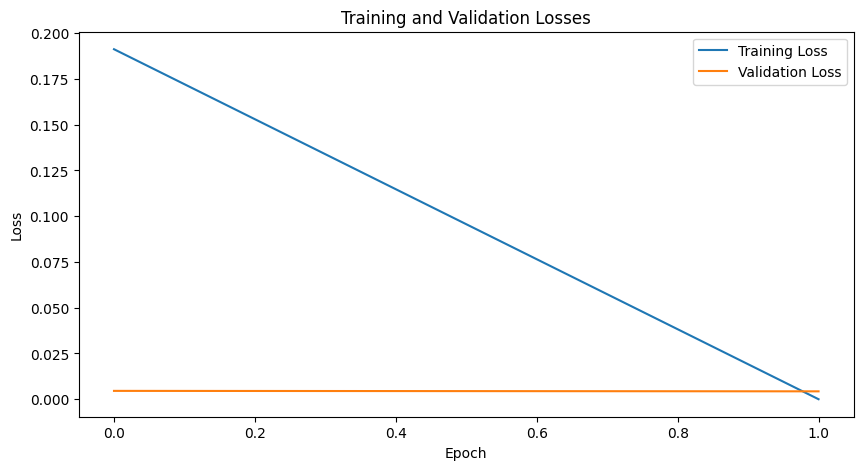

In [76]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

class EmbeddingDataset(Dataset):
    """
    Custom Dataset for Embedding Tensors
    """
    def __init__(self, embeddings):
        """
        Args:
            embeddings (torch.Tensor or numpy.ndarray): Input embeddings
        """
        # Convert to torch tensor if not already
        if not torch.is_tensor(embeddings):
            embeddings = torch.tensor(embeddings, dtype=torch.float32)
        
        # Ensure 3D tensor (batch, 1, features)
        if embeddings.dim() == 2:
            embeddings = embeddings.unsqueeze(1)
        
        self.embeddings = embeddings
    
    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return self.embeddings[idx]

class SparseEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        """
        Sparse Encoder with semantic feature generation
        
        Args:
            input_dim (int): Input feature dimension
            hidden_dim (int): Hidden layer dimension
        """
        super(SparseEncoder, self).__init__()
        
        # Encoder layers
        
        # Sparsity-inducing layer
        self.sparse_layer = nn.Linear(input_dim, hidden_dim)
        
    def forward(self, x):
        """
        Forward pass of the Sparse Encoder
        
        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, 1, input_dim)
        
        Returns:
            torch.Tensor: Sparse semantic features
        """
        # Flatten input if needed
        x = x.view(x.size(0), -1)
        
        # Encode
        
        # Induce sparsity
        sparse_features = torch.relu(self.sparse_layer(x))
        
        return sparse_features

def prepare_data(embeddings, test_split=0.2, batch_size=32):
    """
    Prepare data for training and testing
    
    Args:
        embeddings (torch.Tensor or numpy.ndarray): Input embeddings
        test_split (float): Proportion of data to use for testing
        batch_size (int): Batch size for DataLoader
    
    Returns:
        tuple: (train_loader, test_loader, input_dim)
    """
    # Convert to tensor if not already
    if not torch.is_tensor(embeddings):
        embeddings = torch.tensor(embeddings, dtype=torch.float32)
    
    # Ensure 3D tensor (batch, 1, features)
    if embeddings.dim() == 2:
        embeddings = embeddings.unsqueeze(1)
    
    # Get input dimension
    input_dim = embeddings.size(-1)
    
    # Calculate split index
    split_idx = int(len(embeddings) * (1 - test_split))
    
    # Split data
    train_embeddings = embeddings[:split_idx]
    test_embeddings = embeddings[split_idx:]
    
    # Create datasets
    train_dataset = EmbeddingDataset(train_embeddings)
    test_dataset = EmbeddingDataset(test_embeddings)
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False
    )
    
    return train_loader, test_loader, input_dim

def train_sparse_encoder(model, train_loader, test_loader, epochs=2, learning_rate=1e-3):
    """
    Train the Sparse Encoder
    
    Args:
        model (SparseEncoder): Sparse Encoder model
        train_loader (DataLoader): Training data loader
        test_loader (DataLoader): Testing data loader
        epochs (int): Number of training epochs
        learning_rate (float): Learning rate for optimizer
    
    Returns:
        tuple: (training_losses, validation_losses)
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Reconstruction loss (using MSE)
    criterion = nn.MSELoss()
    
    # Sparsity loss component
    def sparsity_loss(features):
        return torch.mean(torch.abs(features))
    
    training_losses = []
    validation_losses = []
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_epoch_loss = 0
        
        for batch in train_loader:
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            sparse_features = model(batch)
            
            # Compute loss (MSE + Sparsity regularization)
            mse_loss = criterion(sparse_features, torch.zeros_like(sparse_features))
            sparse_reg = sparsity_loss(sparse_features)
            total_loss = mse_loss + 0.01 * sparse_reg
            
            # Backward pass
            total_loss.backward()
            optimizer.step()
            
            train_epoch_loss += total_loss.item()
        
        # Average training loss
        avg_train_loss = train_epoch_loss / len(train_loader)
        training_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_epoch_loss = 0
        
        with torch.no_grad():
            for batch in test_loader:
                sparse_features = model(batch)
                
                # Compute validation loss
                mse_loss = criterion(sparse_features, torch.zeros_like(sparse_features))
                sparse_reg = sparsity_loss(sparse_features)
                total_loss = mse_loss + 0.01 * sparse_reg
                
                val_epoch_loss += total_loss.item()
        
        # Average validation loss
        avg_val_loss = val_epoch_loss / len(test_loader)
        validation_losses.append(avg_val_loss)
        
        # Print progress
        if epoch % 10 == 0:
            print(f"Epoch {epoch}")
            print(f"Training Loss: {avg_train_loss:.4f}")
            print(f"Validation Loss: {avg_val_loss:.4f}")
    
    return training_losses, validation_losses

def save_model(model, filepath='sparse_encoder.pth'):
    """
    Save the trained model
    
    Args:
        model (SparseEncoder): Trained Sparse Encoder model
        filepath (str): Path to save the model
    """
    torch.save(model.state_dict(), filepath)
    print(f"Model saved to {filepath}")

def load_model(input_dim, hidden_dim=128, filepath='sparse_encoder.pth'):
    """
    Load a saved Sparse Encoder model
    
    Args:
        input_dim (int): Input feature dimension
        hidden_dim (int): Hidden layer dimension
        filepath (str): Path to load the model from
    
    Returns:
        SparseEncoder: Loaded model
    """
    model = SparseEncoder(input_dim, hidden_dim)
    model.load_state_dict(torch.load(filepath))
    model.eval()
    return model

def inference(model, input_data):
    """
    Perform inference with the Sparse Encoder
    
    Args:
        model (SparseEncoder): Trained Sparse Encoder model
        input_data (torch.Tensor): Input tensor
    
    Returns:
        torch.Tensor: Sparse semantic features
    """
    with torch.no_grad():
        sparse_features = model(input_data)
    return sparse_features

def main():
    # Example usage
    # Generate some sample embeddings (replace this with your actual embeddings)
    sample_embeddings = embeddings_of_hidden.float()
    
    # Prepare data
    train_loader, test_loader, input_dim = prepare_data(
        sample_embeddings, 
        test_split=0.2, 
        batch_size=100
    )
    
    # Create model
    sparse_encoder = SparseEncoder(input_dim, hidden_dim=3584)
    
    # Train the model
    train_losses, val_losses = train_sparse_encoder(
        sparse_encoder, 
        train_loader, 
        test_loader
    )
    
    # Save the model
    save_model(sparse_encoder)
    # Optional: Visualize or analyze losses
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

In [78]:
def update_hidden_using_sperse(model, filepath='embedding_data.npy'):
    """
    Load embedding data from a saved file
    
    Args:
        filepath (str): Path to load the embedding data from
    
    Returns:
        np.ndarray: Loaded embedding data
    """

    data = torch.load(filepath)
    hiden_states =data['hidden_states']
    emd = []
    
    for  hiden_state in hiden_states:
        indiv_hidden = {}
        for hidden_key, hidden_value in hiden_state.items():
            indiv_hidden[hidden_key] = model(hidden_value.float())
        emd.append(indiv_hidden)

    
    data['hidden_states'] = emd
    torch.save(data, "/mnt/abka03/xl-vlms/features/sperced_modified_save_hidden_states_qwen2_image_patched_patch_concept_generation_split_train.pth")


file_path= "/mnt/abka03/xl-vlms/features/modified_save_hidden_states_qwen2_image_patched_patch_concept_generation_split_train.pth"
model = load_model(input_dim= 3584, hidden_dim=3584, filepath='sparse_encoder.pth')
update_hidden_using_sperse(model, file_path)